# Modeling

In the previous codelab session, you cleaned and prepared the quantities of interest in the ESS10 data, relevant to our hypothesis:

> **Centrist individuals exhibit lower levels of affective polarisation.**

In this codelab, we will:

1. Load the preprocessed ESS data
2. Specify and estimate a sequence of linear regression models
3. Compare models to understand how the centrism coefficient changes
4. Interpret the results in relation to our hypothesis
5. Bonus - create a visualization of the results

### Learning Objectives

- Understand how to specify and interpret a **linear regression model** using `statsmodels` (formula API)
- Apply modelling to the ESS dataset by estimating nested models
- Compare models and reflect on potential confounding and robustness

### Tips

- You should adapt code from previous [notebooks](https://github.com/mickaeltemporao/materials/tree/main), mostly from:
    - `07-data-modeling-insights.ipynb`


## Loading the Data

We'll use the preprocessing function we created to load a clean, modelling-ready dataset.

A new function has been added/defined inside `code/preprocess.py` take a look!
- it is called `clean_data`

In [11]:
# Import necessary libraries
import sys
import pandas as pd

# Adding the code directory to path
sys.path.append('../code')

# Import the preprocessing function
from preprocess import clean_data

from statsmodels.iolib.summary2 import summary_col

In [2]:
# Load the preprocessed data
df = clean_data()
df.sample(5)

❗ CSV not found. Downloading ZIP...
📦 ZIP downloaded to: data/raw/data.zip
📂 Extracting ZIP...
✅ Files extracted to: data/raw/


c:\Users\baptj\OneDrive\Documents\paper-spsc-2026\group-2\../code\data.py:45: DtypeWarning: Columns (166,172,174,607,608) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(csv_path)


,agea,clsprty,gndr,hinctnta,lrscale,polintr,prtclffr,prtdgcl,prtvtefr,vote,centrism,affective_polarization,female
13126,54,1,2,10,6,3,6.0,2,66.0,2,1,0.350,1
12086,20,2,1,6,10,3,66.0,6,66.0,3,0,0.275,0
11689,62,2,2,7,5,2,66.0,6,6.0,1,1,0.450,1
12884,65,2,2,5,4,3,66.0,6,66.0,8,1,0.575,1
13088,54,2,1,5,5,3,66.0,6,88.0,1,1,0.750,0


In [3]:
# Check the key variables for our analysis
df.describe()

,agea,clsprty,gndr,hinctnta,lrscale,polintr,prtclffr,prtdgcl,prtvtefr,vote,centrism,affective_polarization,female
count,1564.000000,1564.000000,1564.000000,1564.000000,1564.000000,1564.000000,1564.000000,1564.000000,1564.000000,1564.000000,1564.000000,1564.000000,1564.000000
mean,50.157928,1.581202,1.494885,6.444373,5.050512,2.554987,39.189898,4.358056,36.654092,1.669437,0.494885,0.563251,0.494885
std,17.839011,0.764992,0.500134,2.945893,2.265631,0.960603,29.693816,1.855201,30.668891,1.151954,0.500134,0.183284,0.500134
min,16.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,36.000000,1.000000,1.000000,4.000000,4.000000,2.000000,7.000000,2.000000,7.000000,1.000000,0.000000,0.425000,0.000000
50%,51.000000,2.000000,1.000000,7.000000,5.000000,3.000000,66.000000,6.000000,13.000000,1.000000,0.000000,0.550000,0.000000
75%,64.000000,2.000000,2.000000,9.000000,7.000000,3.000000,66.000000,6.000000,66.000000,2.000000,1.000000,0.700000,1.000000
max,90.000000,8.000000,2.000000,10.000000,10.000000,4.000000,88.000000,6.000000,88.000000,8.000000,1.000000,1.000000,1.000000


## Building Regression Models

Use the **`statsmodels` formula API** to specify regression models. 

```
DV ~ IV + Control_1 + Control_2
```

**Key points:**
- The dependent variable (DV) goes on the left side of the `~`
- Independent variables go on the right side
- Categorical variables should be wrapped in `C()` to ensure proper treatment

Start by loading statsmodels formula api as `sm`.

In [5]:
import statsmodels.formula.api as sm


### Model 1: Baseline Model

Our first model is a **baseline** that examines the relationship between centrism and affective polarisation **without any control variables**.

**Task:**
1. Specify a formula with `affective_polarisation` as the DV and `centrism` as the IV
2. Fit the model using `sm.ols()`
3. Print the model summary

In [7]:
# Your code here:
# Define the baseline formula and save it to `formula_baseline``
formula_baseline="affective_polarization ~ C(centrism)"
# Fit the model using the created formula and the prepared dataset
model = sm.ols(formula=formula_baseline, data=df).fit()
# Print the summary
print(model.summary())

                              OLS Regression Results                              
Dep. Variable:     affective_polarization   R-squared:                       0.001
Model:                                OLS   Adj. R-squared:                  0.000
Method:                     Least Squares   F-statistic:                     1.581
Date:                    Wed, 18 Mar 2026   Prob (F-statistic):              0.209
Time:                            10:26:58   Log-Likelihood:                 435.74
No. Observations:                    1564   AIC:                            -867.5
Df Residuals:                        1562   BIC:                            -856.8
Df Model:                               1                                         
Covariance Type:                nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------


### Model 2: Adding Demographic Controls

Now let's add **key demographic controls** to see how the relationship with your DV evolves.

Include:
- **Age** (`agea`)
- **Gender** (`female`)
- **Income** (`hinctnta`)


**Note:** If we had a categorical variable with multiple groups, we'd use `C()`.

**Task:**
1. Extend the formula to include key control variables 
2. Fit the model
3. Print the summary

In [8]:
# Your code here:
# Define formula_controls with key demographic controls
formula_demo="affective_polarization ~ agea + female + hinctnta + C(centrism)"
# Fit the model
model_demo=sm.ols(formula=formula_demo, data=df).fit()
# Print the summary
print(model_demo.summary())

                              OLS Regression Results                              
Dep. Variable:     affective_polarization   R-squared:                       0.028
Model:                                OLS   Adj. R-squared:                  0.025
Method:                     Least Squares   F-statistic:                     11.19
Date:                    Wed, 18 Mar 2026   Prob (F-statistic):           5.96e-09
Time:                            10:28:31   Log-Likelihood:                 457.08
No. Observations:                    1564   AIC:                            -904.2
Df Residuals:                        1559   BIC:                            -877.4
Df Model:                               4                                         
Covariance Type:                nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------


### Model 3: Fully Specified Model

Finally, let's add other key controls variables that are relevant to our hypothesis:

- **Political interest** (`polintr`)
- **Ideology** (`lrscale`) 

**Task:**
1. Create a formula that includes all previous variables plus `prtclffr` and `lrscale`
2. Fit the model
3. Print the summary

In [9]:
# Your code here:
# Define formula_final with the added key control variables
formula_cntrl="affective_polarization ~ agea + female + hinctnta + C(centrism) + polintr + C(lrscale)"
# Fit the model
model_cntrl=sm.ols(formula=formula_cntrl, data=df).fit()
# Print the summary
print(model_cntrl.summary())

                              OLS Regression Results                              
Dep. Variable:     affective_polarization   R-squared:                       0.091
Model:                                OLS   Adj. R-squared:                  0.083
Method:                     Least Squares   F-statistic:                     11.09
Date:                    Wed, 18 Mar 2026   Prob (F-statistic):           1.42e-24
Time:                            10:30:52   Log-Likelihood:                 509.64
No. Observations:                    1564   AIC:                            -989.3
Df Residuals:                        1549   BIC:                            -909.0
Df Model:                              14                                         
Covariance Type:                nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------


## Comparing Models

Let's compare all three models side-by-side using `summary_col()`.

In [13]:
# Compare the three models
my_models=[model,model_demo,model_cntrl]
summary_col(my_models)

,affective_polarization I,affective_polarization II,affective_polarization III
Intercept,0.5690,0.6535,0.5801
,(0.0065),(0.0196),(0.0318)
C(centrism)[T.1],-0.0117,-0.0141,-0.0695
,(0.0093),(0.0092),(0.0174)
agea,,-0.0003,0.0001
,,(0.0003),(0.0003)
female,,-0.0042,-0.0183
,,(0.0092),(0.0091)
hinctnta,,-0.0103,-0.0063
,,(0.0016),(0.0016)


## Interpretation

**Key questions to consider:**

1. **Coefficient stability:** How does the `centrism` coefficient change across models?
2. **Statistical significance:** Is `centrism` statistically significant in all models?
3. **Direction of effect:** Is the coefficient positive or negative? What does this mean for our hypothesis?
4. **Confounding:** Do the demographic controls substantially change the centrism coefficient? What does this suggest?
5. **Model fit:** How does R-squared change as we add controls?

**So What?**
> Do centrist individuals exhibit lower affective polarisation?

Based on the model results, what can we conclude about our hypothesis?

## (Optional) Visualisation

Try creating a publication-ready figure showing the relationship between centrism and affective polarisation. You may use any library you like and seek help (e.g. using online resources or tools such as ChatGPT...) to produce the most effective figure you can. Try to make it look great!

You should explore modern python visualisation libraries.
- avoid using matplotlib, there are many great dataviz libraries out there
    - see https://github.com/gribouille/awesome-python?tab=readme-ov-file#data-visualization

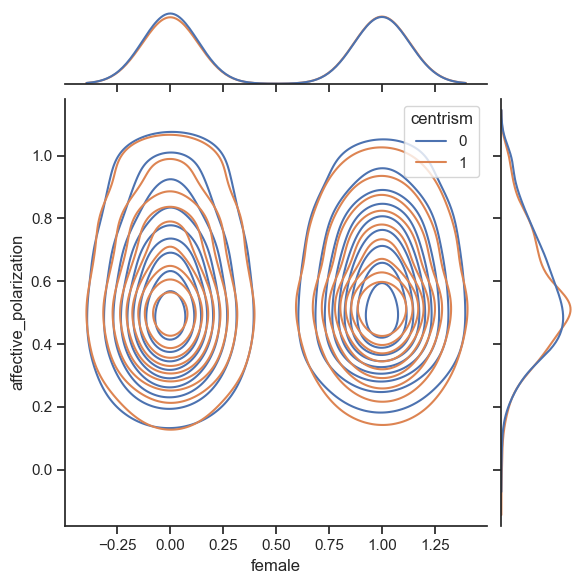

In [19]:
# Your code here
import seaborn as sns
sns.set_theme(style="ticks")

# Load the penguins dataset
penguins = df

# Show the joint distribution using kernel density estimation
g = sns.jointplot(
    data=penguins,
    x="female", y="affective_polarization", hue="centrism",
    kind="kde",
)

<Axes: xlabel='centrism', ylabel='affective_polarization'>

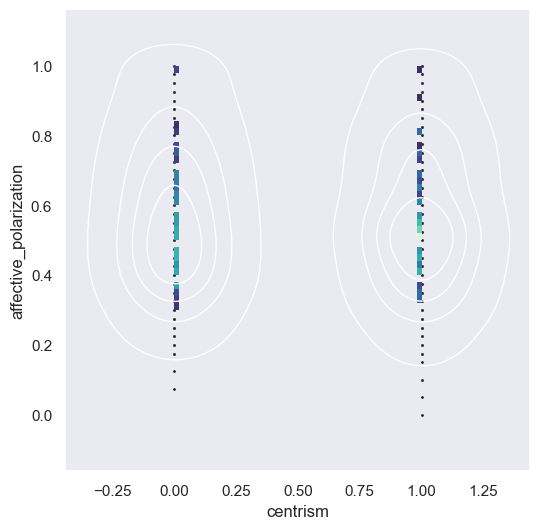

In [23]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="dark")

# Simulate data from a bivariate Gaussian
# n = 10000
# mean = [0, 0]
# cov = [(2, .4), (.4, .2)]
# rng = np.random.RandomState(0)
# x, y = rng.multivariate_normal(mean, cov, n).T

# Draw a combo histogram and scatterplot with density contours
data=df
f, ax = plt.subplots(figsize=(6, 6))
sns.scatterplot(data=df, x="centrism", y="affective_polarization", s=5, color=".15")
sns.histplot(data=df, x="centrism", y="affective_polarization", bins=50, pthresh=.1, cmap="mako")
sns.kdeplot(data=df, x="centrism", y="affective_polarization", levels=5, color="w", linewidths=1)

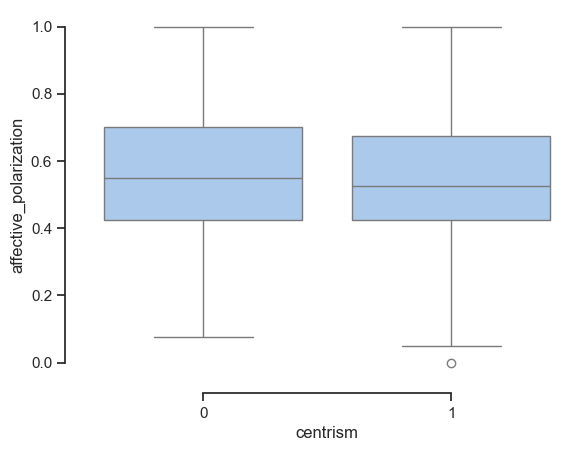

In [25]:
sns.set_theme(style="ticks", palette="pastel")

# Draw a nested boxplot to show bills by day and time
sns.boxplot(data=df, x="centrism", y="affective_polarization"),
sns.despine(offset=10, trim=True)

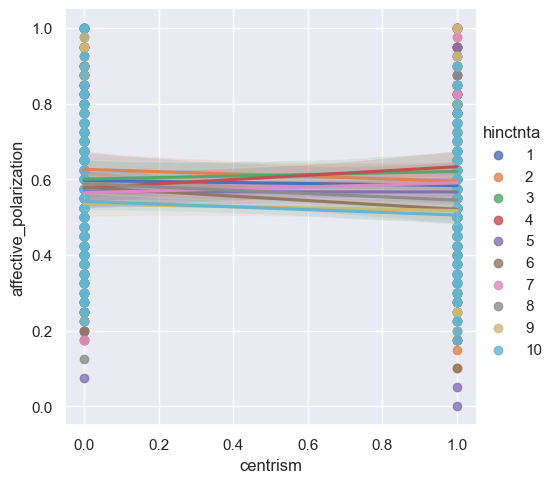

In [26]:
sns.set_theme()


# Plot sepal width as a function of sepal_length across days
g = sns.lmplot(
    data=df,
    x="centrism", y="affective_polarization", hue="hinctnta",
    height=5
)

# Use more informative axis labels than are provided by default
g.set_axis_labels("centrism", "affective_polarization")